# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 9s 0us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

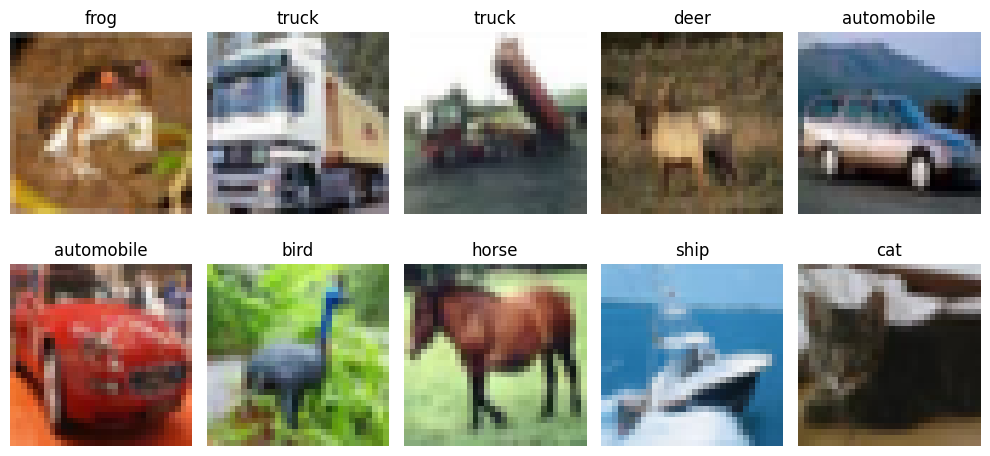

In [3]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [4]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [12]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),  # added layer
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),  # added layer
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# increased epochs to 20, added EarlyStopping
ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 37ms/step - accuracy: 0.2320 - loss: 2.0459 - val_accuracy: 0.3104 - val_loss: 1.9191
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 39s 34ms/step - accuracy: 0.2856 - loss: 1.9170 - val_accuracy: 0.3122 - val_loss: 1.8583
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 34ms/step - accuracy: 0.3051 - loss: 1.8747 - val_accuracy: 0.3078 - val_loss: 1.8310
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 42s 35ms/step - accuracy: 0.3207 - loss: 1.8450 - val_accuracy: 0.3656 - val_loss: 1.7997
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 34ms/step - accuracy: 0.3275 - loss: 1.8251 - val_accuracy: 0.3656 - val_loss: 1.7712
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 32ms/step - accuracy: 0.3359 - loss: 1.8080 - val_accuracy: 0.3814 - val_loss: 1.7323
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 34ms/step - accuracy: 0.3426 - loss: 1.7953 - val_accuracy: 0.3948 - val_loss: 1.7489
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 33ms/step - accuracy: 0.3468 - loss: 1.7828 - 

In [13]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4246 - loss: 1.6471
ANN Test Accuracy: 0.4246000051498413


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [14]:
cnn_model = models.Sequential([
    # changed filters from 32 to 64
    layers.Conv2D(64, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    # changed filters from 64 to 128
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    # changed filters from 128 to 256
    layers.Conv2D(256, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# increased epochs to 20, added EarlyStopping
cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 261s 366ms/step - accuracy: 0.4510 - loss: 1.5428 - val_accuracy: 0.4532 - val_loss: 1.5539
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 249s 354ms/step - accuracy: 0.6003 - loss: 1.1378 - val_accuracy: 0.4636 - val_loss: 1.5252
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 267s 362ms/step - accuracy: 0.6702 - loss: 0.9469 - val_accuracy: 0.5272 - val_loss: 1.4429
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 258s 367ms/step - accuracy: 0.7206 - loss: 0.8093 - val_accuracy: 0.6572 - val_loss: 0.9847
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 259s 362ms/step - accuracy: 0.7558 - loss: 0.7026 - val_accuracy: 0.6642 - val_loss: 1.0016
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 253s 359ms/step - accuracy: 0.7882 - loss: 0.6092 - val_accuracy: 0.7172 - val_loss: 0.8525
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 257s 365ms/step - accuracy: 0.8151 - loss: 0.5252 - val_accuracy: 0.7076 - val_loss: 1.0083
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 262s 372ms/step - accuracy: 0.8376 -

In [15]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 42ms/step - accuracy: 0.7094 - loss: 0.8852
CNN Test Accuracy: 0.7093999981880188


## 📈 Compare Learning Curves

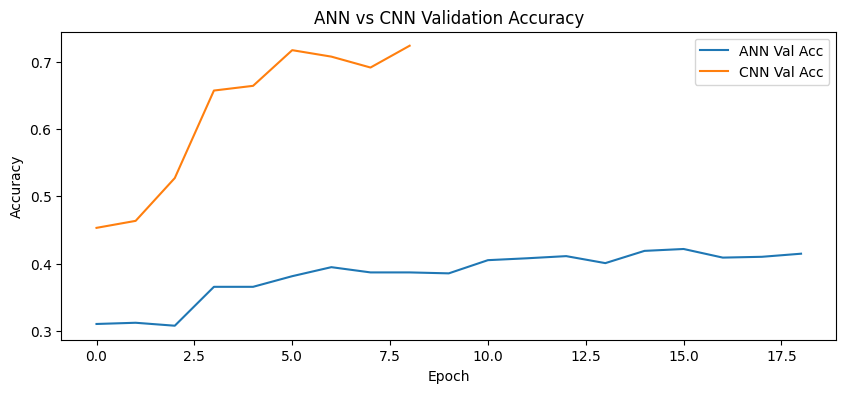

In [16]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [19]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    # same filter changes as CNN above
    layers.Conv2D(64, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# training augmented CNN with EarlyStopping
aug_history = aug_cnn_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 231s 323ms/step - accuracy: 0.3643 - loss: 1.8029 - val_accuracy: 0.4424 - val_loss: 1.5574
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 229s 325ms/step - accuracy: 0.4556 - loss: 1.5228 - val_accuracy: 0.4868 - val_loss: 1.4278
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 222s 316ms/step - accuracy: 0.5042 - loss: 1.4006 - val_accuracy: 0.5254 - val_loss: 1.3527
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 37ms/step - accuracy: 0.4311 - loss: 1.5970


# 📊 Final Comparison Table

In [11]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4326
1,CNN,0.7127


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**